In [1]:
import pandas as pd
import numpy as np

## Load the age and the sex for the UK BioBank subjects

In [2]:
sex_age_df = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/participants_sex_age.csv")
sex_age_df

,Subject,Sex,Age
0,sub-3411469,1,65.0
1,sub-2290292,0,69.0
2,sub-3842391,0,70.0
3,sub-2758537,1,49.0
4,sub-4334619,1,70.0
...,...,...,...
42781,sub-5057890,1,72.0
42782,sub-2038574,1,70.0
42783,sub-1415693,0,64.0
42784,sub-4524619,1,66.0


array([[<AxesSubplot:title={'center':'Sex'}>,
        <AxesSubplot:title={'center':'Age'}>]], dtype=object)

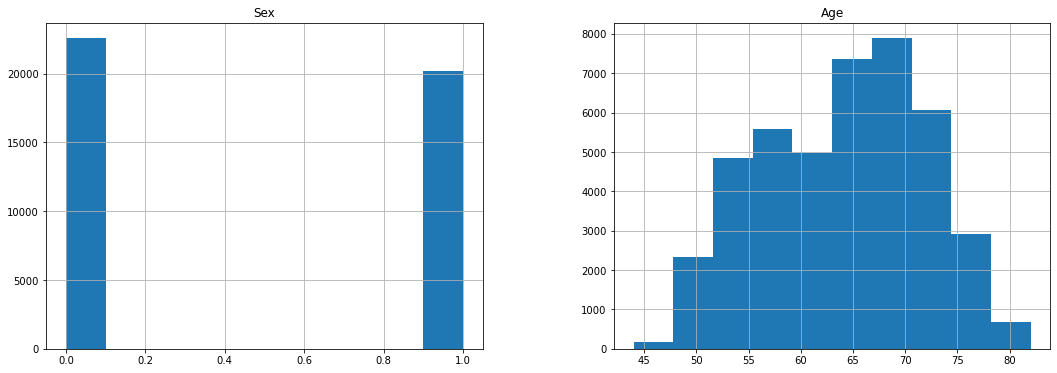

In [3]:
sex_age_df.hist(figsize=(18, 6))

### Split the dataset into 10 deciles, based on the age

In [4]:
# adding Decile_rank column to the DataFrame 
sex_age_df['Decile_rank'] = pd.qcut(sex_age_df['Age'], 10, 
                            labels = False)
sex_age_df

,Subject,Sex,Age,Decile_rank
0,sub-3411469,1,65.0,5
1,sub-2290292,0,69.0,6
2,sub-3842391,0,70.0,7
3,sub-2758537,1,49.0,0
4,sub-4334619,1,70.0,7
...,...,...,...,...
42781,sub-5057890,1,72.0,8
42782,sub-2038574,1,70.0,7
42783,sub-1415693,0,64.0,4
42784,sub-4524619,1,66.0,5


#### Chech the proportion of male and female in the first decile (the "young" subjects)

In [5]:
print(sex_age_df[sex_age_df["Decile_rank"]==0].head())
(sex_age_df[sex_age_df["Decile_rank"]==0][["Sex","Age"]]).mean()

        Subject  Sex   Age  Decile_rank
3   sub-2758537    1  49.0            0
6   sub-1717033    0  52.0            0
8   sub-3798925    0  51.0            0
9   sub-3405143    1  52.0            0
22  sub-5617291    0  51.0            0


Sex     0.439328
Age    51.083800
dtype: float64

#### Chech the proportion of male and female in the last decile (the "old" subjects)

In [6]:
print(sex_age_df[sex_age_df["Decile_rank"]==9].head())
(sex_age_df[sex_age_df["Decile_rank"]==9][["Sex","Age"]]).mean()

         Subject  Sex   Age  Decile_rank
29   sub-2214448    1  75.0            9
72   sub-2186388    1  77.0            9
74   sub-5105357    1  77.0            9
90   sub-5448708    1  79.0            9
103  sub-2695425    0  79.0            9


Sex     0.582891
Age    76.788650
dtype: float64

### Load the quality check files

In [12]:
QC0 = pd.read_csv("/volatile/ad279118/2024_adufournet_sulcus_genetics/notebooks/UKB/QC/outliers.csv")
QC0 = QC0["ID"].to_list()
# we don't want to be in QC0

In [8]:
QC1 = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/qc.tsv", sep="\t")
QC1 = QC1[QC1["qc"]==1]["participant_id"]
QC1
# we want to be in QC0

1        sub-1000021
2        sub-1000325
3        sub-1000458
4        sub-1000575
5        sub-1000606
            ...     
42762    sub-6023847
42763    sub-6024038
42764    sub-6024150
42765    sub-6024379
42766    sub-6024754
Name: participant_id, Length: 42433, dtype: object

### Pick randomly 
  - 25 females among the first decile

  - 25 males among the first decile

  - 25 females among the last decile

  - 25 males among the last decile

  that are all good according to both QC

In [58]:
seed=42

In [59]:
firstDecile = sex_age_df[sex_age_df["Decile_rank"]==0]
firstDecile = pd.merge(firstDecile, QC1, left_on='Subject', right_on='participant_id', how='inner')
firstDecile = firstDecile.drop(["participant_id","Decile_rank"], axis=1)
firstDecile = firstDecile[~firstDecile["Subject"].isin(QC0)]

firstDecile[firstDecile["Sex"]==1].sample(n=25, random_state=seed)


,Subject,Sex,Age
506,sub-4513725,1,51.0
2703,sub-4332048,1,48.0
2654,sub-4716655,1,49.0
2007,sub-4492474,1,51.0
79,sub-1563022,1,49.0
1096,sub-5045094,1,52.0
2552,sub-2958965,1,51.0
3748,sub-3804665,1,49.0
747,sub-1635113,1,50.0
1289,sub-5444727,1,47.0


In [60]:
lastDecile = sex_age_df[sex_age_df["Decile_rank"]==9]
lastDecile = pd.merge(lastDecile, QC1, left_on='Subject', right_on='participant_id', how='inner')
lastDecile = lastDecile.drop(["participant_id","Decile_rank"], axis=1)
lastDecile = lastDecile[~lastDecile["Subject"].isin(QC0)]

lastDecile[lastDecile["Sex"]==1].sample(n=25, random_state=seed)

,Subject,Sex,Age
339,sub-1826089,1,75.0
3384,sub-1181387,1,75.0
458,sub-2148983,1,79.0
1974,sub-5318803,1,77.0
2591,sub-2763730,1,75.0
189,sub-2622122,1,76.0
3436,sub-5590067,1,76.0
349,sub-3954032,1,78.0
1104,sub-5734104,1,78.0
404,sub-5985341,1,75.0


In [61]:
df_subjects = (firstDecile[firstDecile["Sex"]==0].sample(n=25, random_state=seed))
df_subjects = pd.concat([df_subjects, firstDecile[firstDecile["Sex"]==1].sample(n=25, random_state=seed)])
df_subjects = pd.concat([df_subjects,lastDecile[lastDecile["Sex"]==0].sample(n=25, random_state=seed)])
df_subjects = pd.concat([df_subjects,lastDecile[lastDecile["Sex"]==1].sample(n=25, random_state=seed)])

In [62]:
df_subjects.to_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/100_SEX_AGE_strat.csv', index=False)